In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

sns.set_palette("husl")

print("="*70)
print("WALMART SALES FORECASTING PROJECT")
print("="*70)

# Load datasets
train = pd.read_csv(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Raw Data\train.csv")
features = pd.read_csv(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Raw Data\features.csv")

print("Data loaded successfully!")

# Display basic info
print(f"   Shape: {train.shape}")
print(f"   Columns: {list(train.columns)}")

print(f"   Shape: {features.shape}")
print(f"   Columns: {list(features.columns)}")

WALMART SALES FORECASTING PROJECT
Data loaded successfully!
   Shape: (421570, 5)
   Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
   Shape: (8190, 12)
   Columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']


In [2]:
# Merge train with features
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

print("\n Datasets merged!")
print(f"   Final shape: {df.shape}")
print(f"   Total columns: {len(df.columns)}")

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print("\n First 5 rows:")
print(df.head())

print("\n Data Info:")
print(df.info())


 Datasets merged!
   Final shape: (421570, 14)
   Total columns: 14

 First 5 rows:
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   
3      1     1 2010-02-26      19403.54      False        46.63       2.561   
4      1     1 2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unem

In [4]:
print("\n Missing Values Analysis:")
print("="*50)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print(" No missing values found!")

# Basic statistics
print("\n Statistical Summary:")
print(df.describe())


 Missing Values Analysis:
           Missing_Count  Percentage
MarkDown2         310322   73.611025
MarkDown4         286603   67.984676
MarkDown3         284479   67.480845
MarkDown1         270889   64.257181
MarkDown5         270138   64.079038

 Statistical Summary:
               Store           Dept                           Date  \
count  421570.000000  421570.000000                         421570   
mean       22.200546      44.260317  2011-06-18 08:30:31.963375104   
min         1.000000       1.000000            2010-02-05 00:00:00   
25%        11.000000      18.000000            2010-10-08 00:00:00   
50%        22.000000      37.000000            2011-06-17 00:00:00   
75%        33.000000      74.000000            2012-02-24 00:00:00   
max        45.000000      99.000000            2012-10-26 00:00:00   
std        12.785297      30.492054                            NaN   

        Weekly_Sales    Temperature     Fuel_Price      MarkDown1  \
count  421570.000000  421570

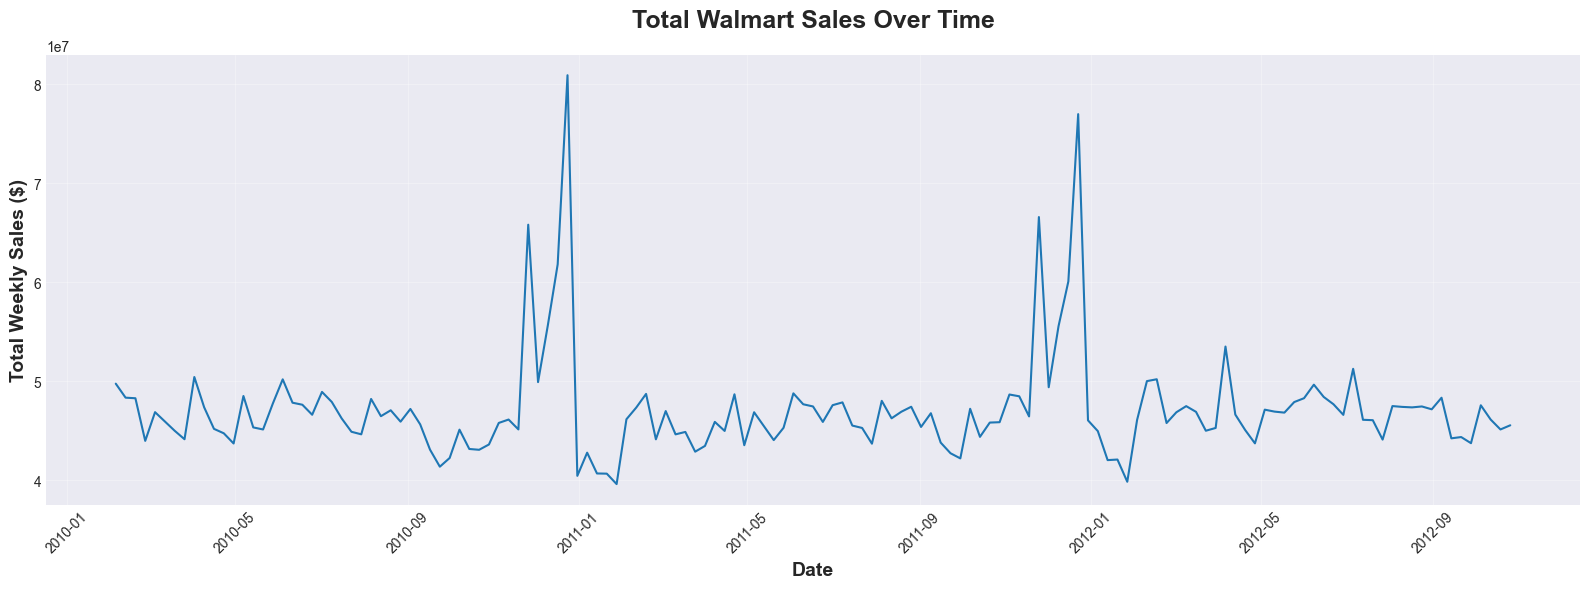

 Plot saved: 01_sales_over_time.png


In [3]:
# Aggregate sales by date
daily_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(16, 6))
plt.plot(daily_sales['Date'], daily_sales['Weekly_Sales'], linewidth=1.5, color='#1f77b4')
plt.title('Total Walmart Sales Over Time', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Total Weekly Sales ($)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/01_sales_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Plot saved: 01_sales_over_time.png")

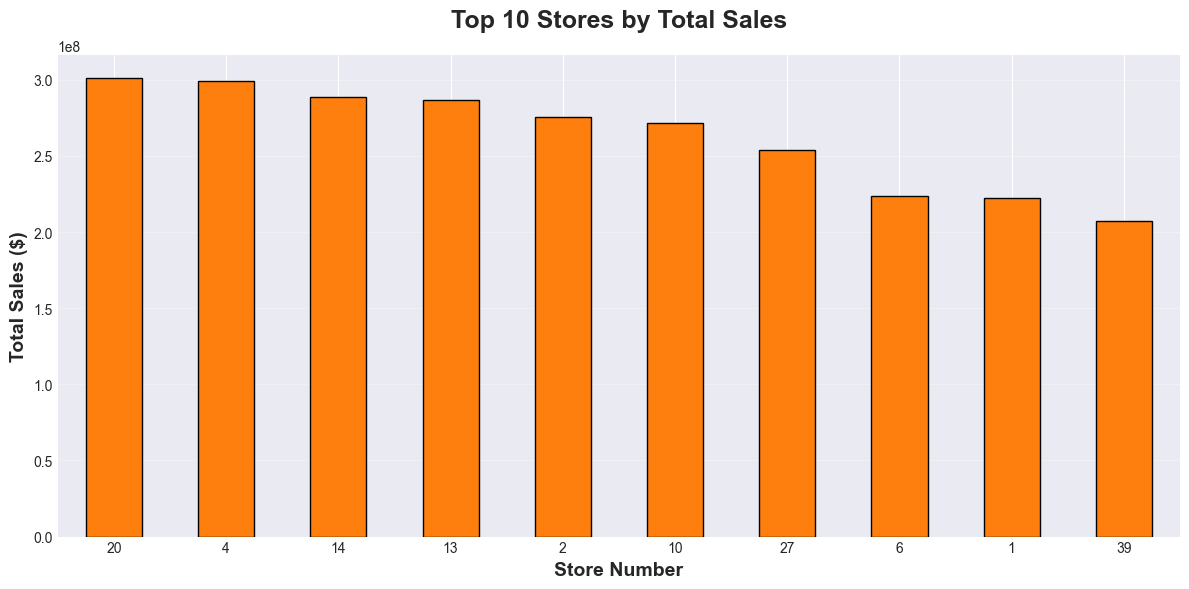

Plot saved

Top 5 Stores:
   1. Store 20: $301,397,792.46
   2. Store 4: $299,543,953.38
   3. Store 14: $288,999,911.34
   4. Store 13: $286,517,703.80
   5. Store 2: $275,382,440.98


In [4]:
# Sales by store
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
store_sales.plot(kind='bar', color='#ff7f0e', edgecolor='black')
plt.title('Top 10 Stores by Total Sales', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Store Number', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/02_sales_by_store.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved")
print(f"\nTop 5 Stores:")
for i, (store, sales) in enumerate(store_sales.head().items(), 1):
    print(f"   {i}. Store {store}: ${sales:,.2f}")

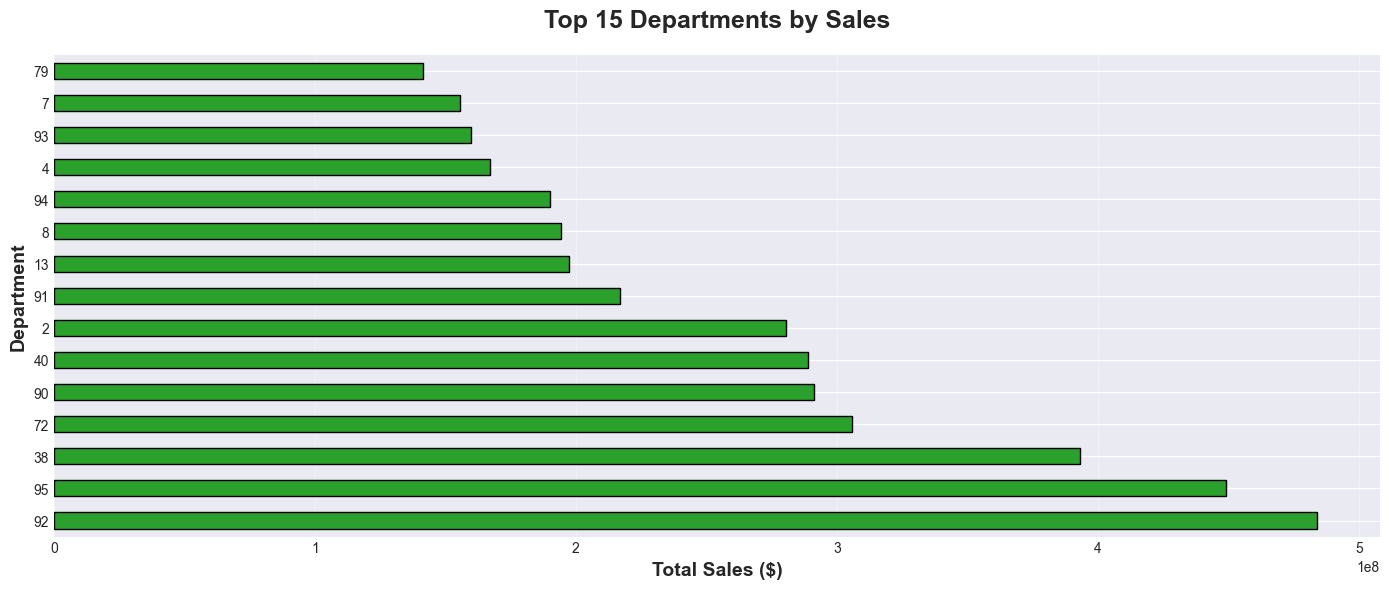

✅ Plot saved


In [5]:
# Sales by department
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
dept_sales.plot(kind='barh', color='#2ca02c', edgecolor='black')
plt.title('Top 15 Departments by Sales', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Sales ($)', fontsize=14, fontweight='bold')
plt.ylabel('Department', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/03_sales_by_dept.png', dpi=300, bbox_inches='tight')
plt.show()

print("plot saved")


 Holiday Impact Analysis:
                   mean           sum   count
IsHoliday                                    
False      15901.445069  6.231919e+09  391909
True       17035.823187  5.052996e+08   29661

 Holiday sales are 7.13% higher than non-holiday sales


<Figure size 1200x600 with 0 Axes>

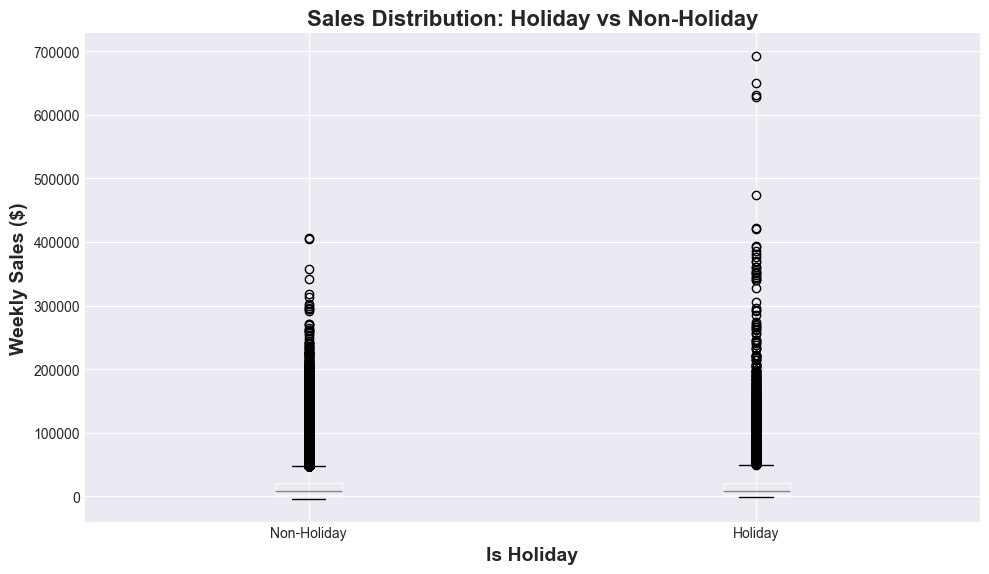

Plot saved


In [6]:
# Holiday vs Non-Holiday
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'sum', 'count'])

print("\n Holiday Impact Analysis:")
print("="*60)
print(holiday_sales)

# Calculate percentage increase
non_holiday_avg = holiday_sales.loc[False, 'mean']
holiday_avg = holiday_sales.loc[True, 'mean']
increase = ((holiday_avg - non_holiday_avg) / non_holiday_avg) * 100

print(f"\n Holiday sales are {increase:.2f}% higher than non-holiday sales")

# Visualization
plt.figure(figsize=(12, 6))
df.boxplot(column='Weekly_Sales', by='IsHoliday', figsize=(10, 6))
plt.title('Sales Distribution: Holiday vs Non-Holiday', fontsize=16, fontweight='bold')
plt.suptitle('')
plt.xlabel('Is Holiday', fontsize=14, fontweight='bold')
plt.ylabel('Weekly Sales ($)', fontsize=14, fontweight='bold')
plt.xticks([1, 2], ['Non-Holiday', 'Holiday'])
plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/04_holiday_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved")

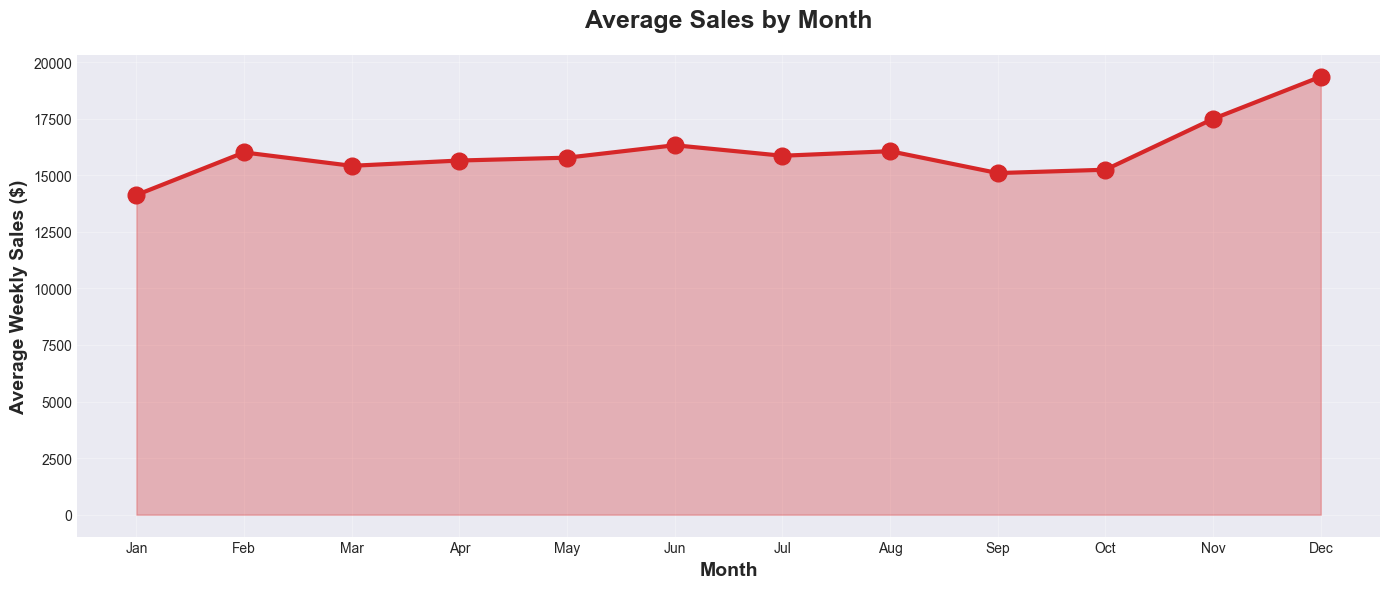

Plot saved

 Peak month: Dec
 Lowest month: Jan


In [7]:
# Extract month from date
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Monthly average sales
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(14, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(monthly_sales['Month'], monthly_sales['Weekly_Sales'], 
         marker='o', markersize=12, linewidth=3, color='#d62728')
plt.fill_between(monthly_sales['Month'], monthly_sales['Weekly_Sales'], alpha=0.3, color='#d62728')
plt.title('Average Sales by Month', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=14, fontweight='bold')
plt.ylabel('Average Weekly Sales ($)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), months)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/05_monthly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved")
print(f"\n Peak month: {months[monthly_sales['Weekly_Sales'].idxmax()]}")
print(f" Lowest month: {months[monthly_sales['Weekly_Sales'].idxmin()]}")

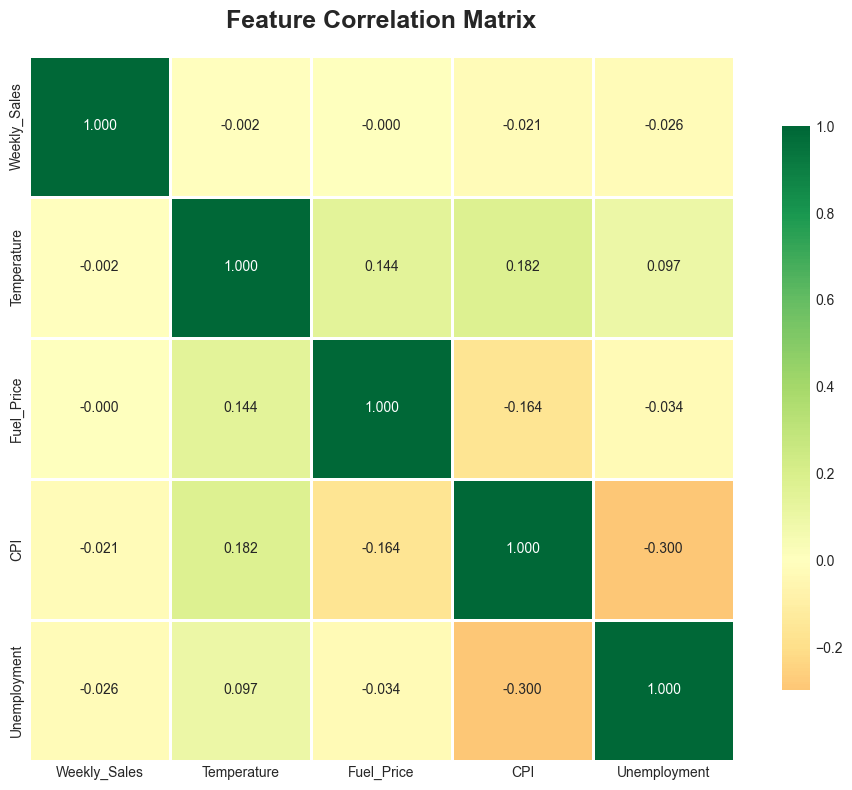

 Plot saved: results/06_correlation.png

 Correlation with Weekly_Sales:
Weekly_Sales    1.000000
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Name: Weekly_Sales, dtype: float64


In [8]:
# Select numeric columns for correlation
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
correlation_data = df[numeric_cols].dropna()

plt.figure(figsize=(10, 8))
correlation_matrix = correlation_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title('Feature Correlation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/06_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Plot saved: results/06_correlation.png")
print("\n Correlation with Weekly_Sales:")
print(correlation_matrix['Weekly_Sales'].sort_values(ascending=False))

In [9]:
print("\n" + "="*70)
print(" WALMART SALES ANALYSIS - SUMMARY REPORT")
print("="*70)

print(f"\n Dataset Overview:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   • Total Days: {(df['Date'].max() - df['Date'].min()).days}")
print(f"   • Number of Stores: {df['Store'].nunique()}")
print(f"   • Number of Departments: {df['Dept'].nunique()}")

print(f"\n Sales Statistics:")
print(f"   • Total Sales: ${df['Weekly_Sales'].sum():,.2f}")
print(f"   • Average Weekly Sales: ${df['Weekly_Sales'].mean():,.2f}")
print(f"   • Median Sales: ${df['Weekly_Sales'].median():,.2f}")
print(f"   • Min Sales: ${df['Weekly_Sales'].min():,.2f}")
print(f"   • Max Sales: ${df['Weekly_Sales'].max():,.2f}")
print(f"   • Std Deviation: ${df['Weekly_Sales'].std():,.2f}")

print(f"\n Holiday Analysis:")
print(f"   • Total Holiday Weeks: {df[df['IsHoliday']==True].shape[0]:,}")
print(f"   • Holiday Sales Boost: +{increase:.2f}%")

print(f"\n Top Performers:")
print(f"   • Best Store: Store #{store_sales.index[0]} (${store_sales.iloc[0]:,.2f})")
print(f"   • Best Department: Dept #{dept_sales.index[0]} (${dept_sales.iloc[0]:,.2f})")

print(f"\n Seasonal Insights:")
print(f"   • Peak Sales Month: {months[monthly_sales['Weekly_Sales'].idxmax()]}")
print(f"   • Lowest Sales Month: {months[monthly_sales['Weekly_Sales'].idxmin()]}")

print("\n 6 visualizations saved in 'results/' folder")
print("\n" + "="*70)
print(" EXPLORATORY DATA ANALYSIS COMPLETE!")
print("="*70)
print("\n Next Steps:")
print("   1. Data Preprocessing")
print("   2. Feature Engineering")
print("   3. Model Building (LSTM, Prophet, XGBoost)")
print("   4. Model Evaluation")
print("   5. Dashboard Creation")


 WALMART SALES ANALYSIS - SUMMARY REPORT

 Dataset Overview:
   • Total Records: 421,570
   • Date Range: 2010-02-05 to 2012-10-26
   • Total Days: 994
   • Number of Stores: 45
   • Number of Departments: 81

 Sales Statistics:
   • Total Sales: $6,737,218,987.11
   • Average Weekly Sales: $15,981.26
   • Median Sales: $7,612.03
   • Min Sales: $-4,988.94
   • Max Sales: $693,099.36
   • Std Deviation: $22,711.18

 Holiday Analysis:
   • Total Holiday Weeks: 29,661
   • Holiday Sales Boost: +7.13%

 Top Performers:
   • Best Store: Store #20 ($301,397,792.46)
   • Best Department: Dept #92 ($483,943,341.87)

 Seasonal Insights:
   • Peak Sales Month: Dec
   • Lowest Sales Month: Jan

 6 visualizations saved in 'results/' folder

 EXPLORATORY DATA ANALYSIS COMPLETE!

 Next Steps:
   1. Data Preprocessing
   2. Feature Engineering
   3. Model Building (LSTM, Prophet, XGBoost)
   4. Model Evaluation
   5. Dashboard Creation
